In [78]:
# laod libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import os
import math
import ast

import torch
pd.set_option('display.max_columns', None)

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [24]:
experiment_results = pd.read_csv("experiment_results/experiment_results_final_benchmark_07222025.csv")
print(experiment_results.shape)
experiment_results.head()

(811, 26)


,Unnamed: 0,experiment_id,model,freeze_layers,dropout_rate,l2-penalty,optimizer,epochs,learning_rate,lr_scheduler_type,train_loss_history,train_roc_auc_history,train_pr_auc_history,train_acc_history,val_loss_history,val_roc_auc_history,val_pr_auc_history,val_acc_history,train_loss,train_roc_auc,train_pr_auc,train_acc,val_loss,val_roc_auc,val_pr_auc,val_acc
0,0,1,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00001,StepLR,"[0.7677282353413025, 0.7067361010065962, 0.691...","[0.499430405965203, 0.5642087821043911, 0.5548...","[0.6138179898262024, 0.646019697189331, 0.6467...","[0.4947468936443329, 0.5950334072113037, 0.583...","[0.7092869424412394, 0.6918016743456197, 0.722...","[0.5321494182486222, 0.44840783833435394, 0.50...","[0.6192221641540527, 0.596264123916626, 0.6191...","[0.5897436141967773, 0.5555555820465088, 0.538...",0.767728,0.499430,0.613818,0.494747,0.709287,0.532149,0.619222,0.589744
1,1,2,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00001,CosineAnnealingWarmRestarts,"[0.728818148346093, 0.6946324272848018, 0.6875...","[0.5615295805333088, 0.5594218908220565, 0.558...","[0.6501603722572327, 0.6492091417312622, 0.650...","[0.5663801431655884, 0.5959885120391846, 0.590...","[0.7033858340010684, 0.6879486344818376, 0.695...","[0.4797917942437232, 0.5030618493570116, 0.521...","[0.5789679288864136, 0.6239730715751648, 0.643...","[0.5897436141967773, 0.5641025900840759, 0.564...",0.679981,0.558618,0.643018,0.596944,0.676083,0.544703,0.678314,0.632479
2,2,3,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00010,StepLR,"[0.9750317388642028, 0.7559583458085228, 0.683...","[0.48983744515020405, 0.5525982693546903, 0.55...","[0.6053346395492554, 0.6566359400749207, 0.651...","[0.5119388699531555, 0.5721107721328735, 0.589...","[0.8120443230001335, 0.7527669270833334, 0.736...","[0.5832823025107164, 0.43478260869565216, 0.52...","[0.7245486974716187, 0.5707476735115051, 0.654...","[0.5299145579338074, 0.5897436141967773, 0.521...",0.755958,0.552598,0.656636,0.572111,0.752767,0.434783,0.570748,0.589744
3,3,4,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00010,CosineAnnealingWarmRestarts,"[0.8838365731517133, 0.7068022952949647, 0.682...","[0.5478900088987082, 0.5425009205560158, 0.562...","[0.6408112049102783, 0.6306596994400024, 0.658...","[0.5587392449378967, 0.5893027782440186, 0.605...","[0.743416028145032, 0.6974972455929487, 0.6922...","[0.5284751990202082, 0.5278628291488059, 0.549...","[0.6523077487945557, 0.6402071118354797, 0.668...","[0.5128205418586731, 0.5470085740089417, 0.538...",0.685774,0.549622,0.652212,0.577841,0.706475,0.426516,0.533404,0.598291
4,4,5,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00100,StepLR,"[2.059432396802201, 0.6889442728037137, 0.6698...","[0.4889188069594035, 0.5492842676976895, 0.587...","[0.6025617718696594, 0.6485717296600342, 0.665...","[0.5100286602973938, 0.5749761462211609, 0.611...","[0.7411092122395834, 0.6939999833066239, 0.682...","[0.5514390691977955, 0.5639926515615432, 0.548...","[0.6186792850494385, 0.646340012550354, 0.6644...","[0.6153846383094788, 0.5384615659713745, 0.547...",2.059432,0.488919,0.602562,0.510029,0.741109,0.551439,0.618679,0.615385


In [4]:
experiment_results.groupby('model').size()

model
ConvNeXt-base-pretrained         90
ConvNeXt-base-pretrained-clip    90
ConvNeXt-base-scratch            90
ResNet-50-pretrained             90
ResNet-50-pretrained-clip        90
ResNet-50-scratch                90
ViT-b32-pretrained               90
ViT-b32-pretrained-clip          90
ViT-b32-scratch                  91
dtype: int64

# Using Resnet to plot the Loss metrics across epochs for Pre-trained and Scratch models in training and validation dataset 

In [50]:
# focus on evaluating the best model settings for each family (i.e. 1 for ResNet, 1 for ViT, 1 for ConvNeXt)
# "best" is open to redefining a bit later depending on model complexity etc. but maybe just go with highest ROC AUC on validation data for now
experiment_results.sort_values(by='val_acc', ascending = False).groupby("model").first()[['experiment_id', 'val_roc_auc', 'val_pr_auc', 'val_pr_auc_history', 'val_acc', 'val_acc_history', 'val_loss', 'train_roc_auc', 'train_pr_auc', 'train_acc', 'train_loss','train_loss_history']]


,experiment_id,val_roc_auc,val_pr_auc,val_pr_auc_history,val_acc,val_acc_history,val_loss,train_roc_auc,train_pr_auc,train_acc,train_loss,train_loss_history
model,,,,,,,,,,,,
ConvNeXt-base-pretrained,46,0.861604,0.919166,"[0.8495288491249084, 0.8886561989784241, 0.891...",0.803419,"[0.6495726704597473, 0.7094017267227173, 0.692...",0.854010,0.999996,0.999998,0.999045,0.010171,"[0.6250131747328678, 0.4505686718959863, 0.342..."
ConvNeXt-base-pretrained-clip,50,0.897428,0.936503,"[0.8374624252319336, 0.8890752792358398, 0.898...",0.846154,"[0.7179487347602844, 0.7264957427978516, 0.717...",0.711118,0.998636,0.999137,0.981853,0.050692,"[0.6262380605440768, 0.4977661832355838, 0.406..."
ConvNeXt-base-scratch,56,0.607165,0.672875,"[0.6806093454360962, 0.6685093641281128, 0.684...",0.658120,"[0.5726495981216431, 0.5726495981216431, 0.564...",0.664588,0.566098,0.660875,0.594078,0.720223,"[0.7390447869797263, 0.7331166672729376, 0.730..."
ResNet-50-pretrained,58,0.852572,0.909620,"[0.8209378719329834, 0.8615625500679016, 0.876...",0.811966,"[0.6239316463470459, 0.6495726704597473, 0.692...",0.677682,0.999580,0.999741,0.992359,0.033567,"[0.6497104356942455, 0.5211538844942022, 0.420..."
ResNet-50-pretrained-clip,51,0.861911,0.910722,"[0.8804112076759338, 0.8804120421409607, 0.906...",0.811966,"[0.6666666865348816, 0.752136766910553, 0.7521...",0.738837,0.999755,0.999850,0.995224,0.027657,"[0.5530227325934963, 0.3068361582933661, 0.138..."
ResNet-50-scratch,17,0.812921,0.852441,"[0.6493244171142578, 0.6674836277961731, 0.747...",0.794872,"[0.4017094075679779, 0.6410256624221802, 0.658...",0.525099,0.868704,0.907902,0.796562,0.436773,"[0.9993066979001108, 0.7354116029930661, 0.619..."
ViT-b32-pretrained,38,0.862829,0.922369,"[0.8586947917938232, 0.8807087540626526, 0.890...",0.820513,"[0.692307710647583, 0.7094017267227173, 0.7350...",0.595384,0.997538,0.998508,0.981853,0.083455,"[0.6841313490553367, 0.5413686612046322, 0.469..."
ViT-b32-pretrained-clip,50,0.876607,0.933870,"[0.8675445318222046, 0.8959347009658813, 0.886...",0.837607,"[0.7094017267227173, 0.7435897588729858, 0.726...",0.609752,0.994571,0.996331,0.974212,0.080009,"[0.5887546776131208, 0.40596503810645745, 0.36..."
ViT-b32-scratch,62,0.639927,0.689035,"[0.7253473997116089, 0.6808043718338013, 0.693...",0.692308,"[0.5470085740089417, 0.6752136945724487, 0.658...",0.640606,0.598751,0.696440,0.607450,0.694077,"[0.8379341351382484, 0.7413221940383984, 0.691..."


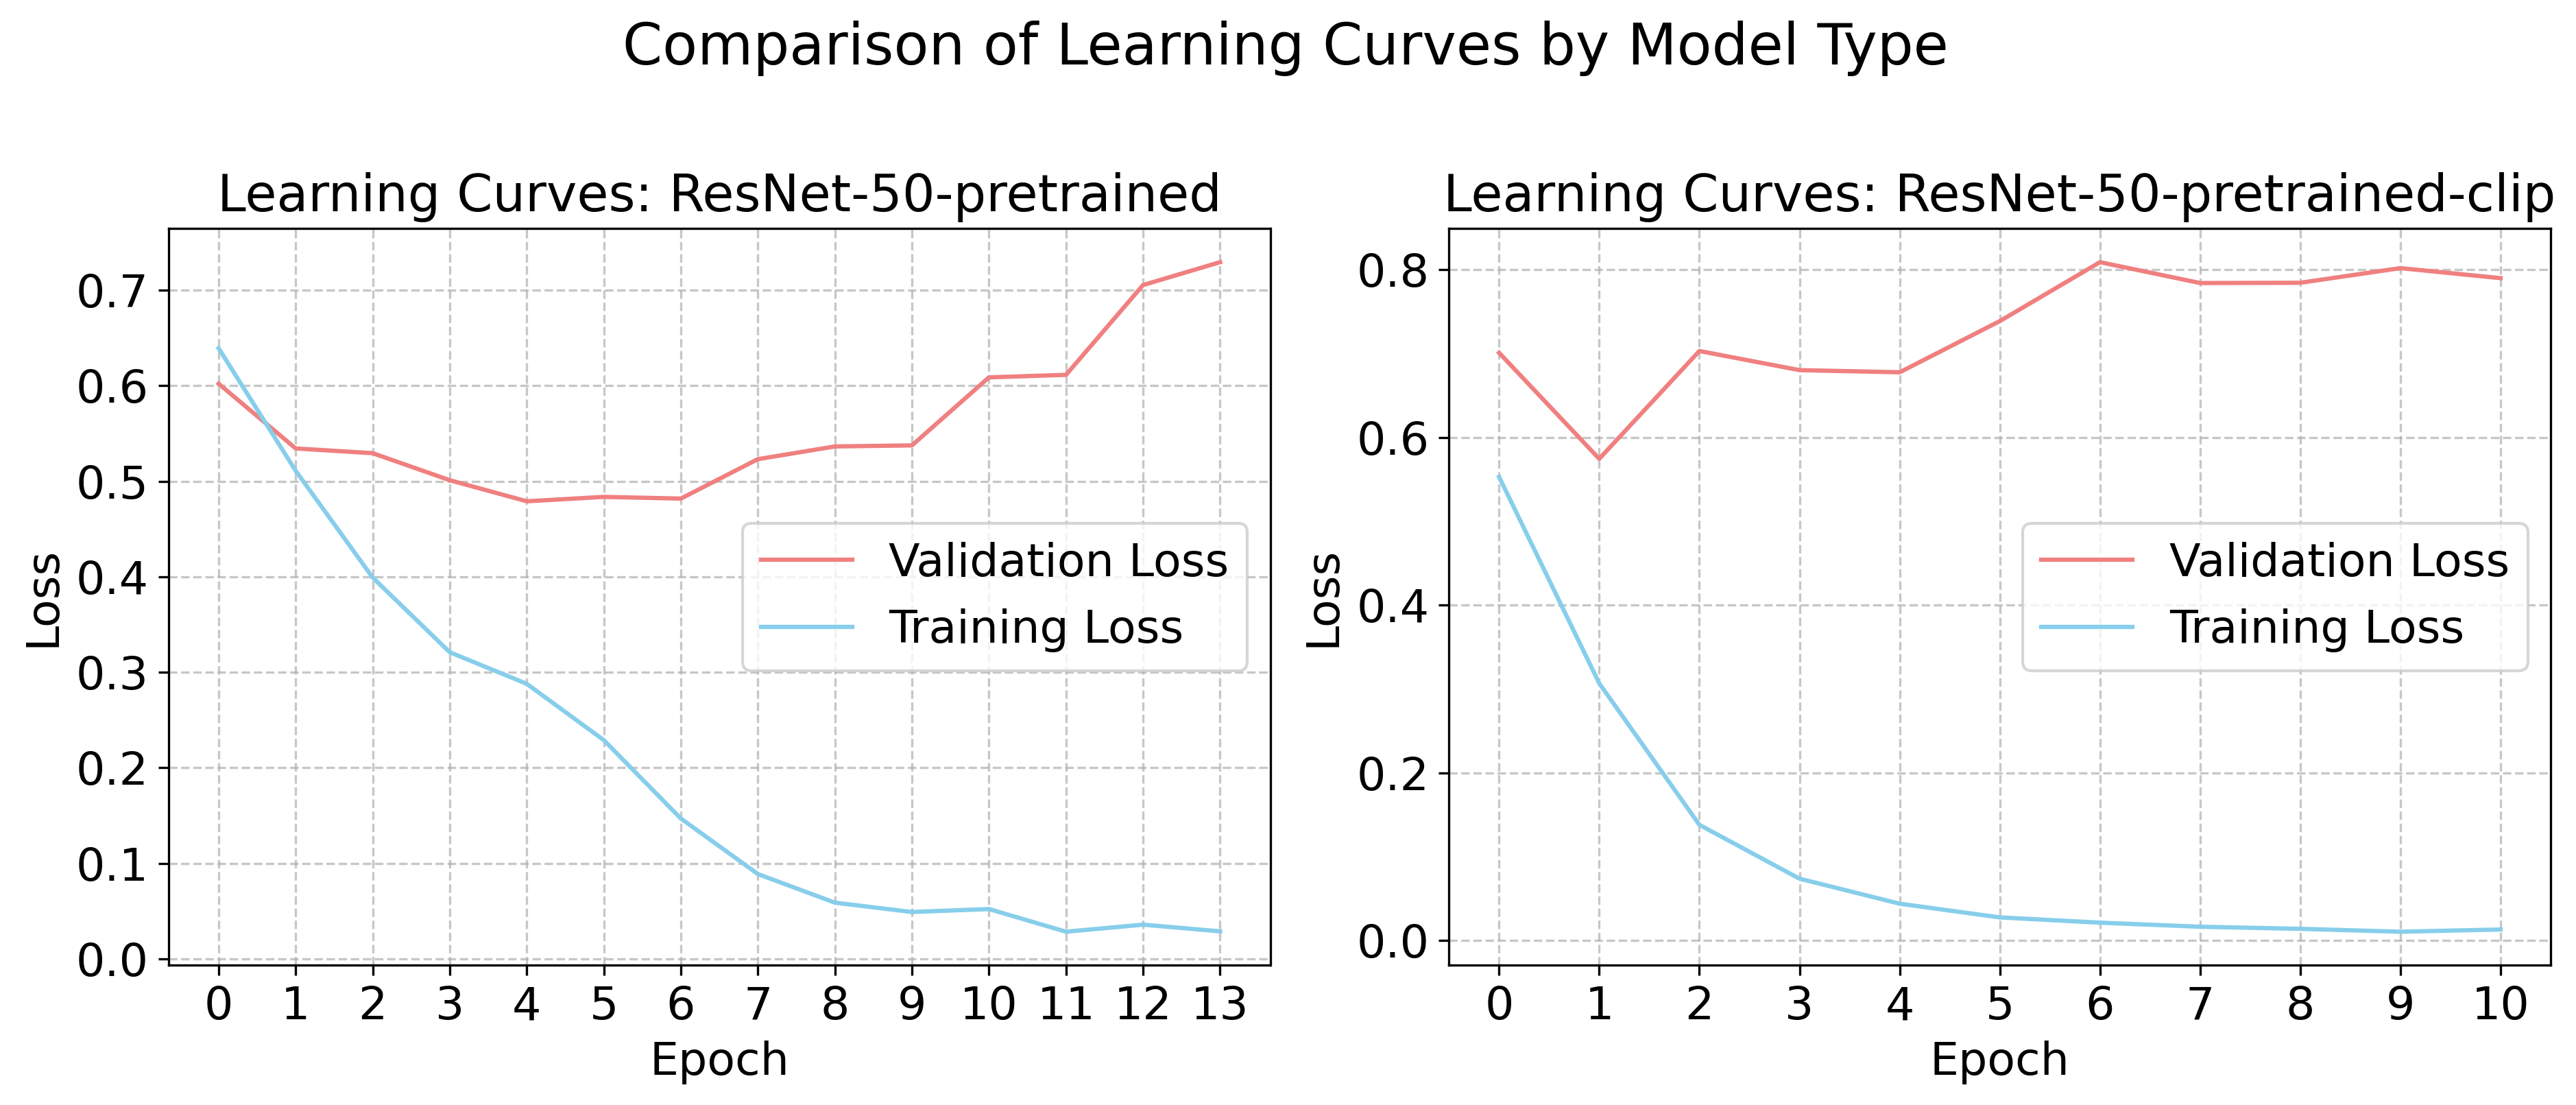

In [91]:
# Define model names
model_type_1 = 'ResNet-50-pretrained'
model_type_2 = 'ResNet-50-pretrained-clip'

# Configuration for Plotting
OUTPUT_DIR = "performance_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURE_WIDTH = 14 
FIGURE_HEIGHT = FIGURE_WIDTH * 0.4 # Adjusted height to maintain aspect ratio
FONTSIZE_TITLE = 18
FONTSIZE_SUBPLOT_TITLE = 18
FONTSIZE_LABELS = 16
FONTSIZE_TICKS = 16
FONTSIZE_LEGEND = 16
DPI = 300

# Create the figure and two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=DPI)

# Process and Plot for Model Type 1: ResNet-50-pretrained
Res_df = experiment_results[experiment_results['model'] == model_type_1]

# Get the best model based on validation accuracy
best_res_model_row = Res_df.sort_values(by='val_acc', ascending=False).iloc[0]

# Extract and convert history data using ast.literal_eval for safety
train_loss_history_res = ast.literal_eval(best_res_model_row['train_loss_history'])
val_loss_history_res = ast.literal_eval(best_res_model_row['val_loss_history'])
NUM_EPOCHS = val_loss_history_res.index(None) # Capture numerical vals and disregard None's

# Plot on the first subplot (axes[0])
axes[0].plot(val_loss_history_res, label='Validation Loss', color='lightcoral')
axes[0].plot(train_loss_history_res, label='Training Loss', color='skyblue')
axes[0].set_xticks(np.arange(0, NUM_EPOCHS, 1)) # Set ticks for each epoch
axes[0].set_title(f'Learning Curves: {model_type_1}', fontsize=FONTSIZE_SUBPLOT_TITLE)
axes[0].set_xlabel('Epoch', fontsize=FONTSIZE_LABELS)
axes[0].set_ylabel('Loss', fontsize=FONTSIZE_LABELS)
axes[0].tick_params(axis='x', labelsize=FONTSIZE_TICKS)
axes[0].tick_params(axis='y', labelsize=FONTSIZE_TICKS)
axes[0].grid(axis='both', linestyle='--', alpha=0.7)
axes[0].legend(fontsize=FONTSIZE_LEGEND)

# Process and Plot for Model Type 2: ResNet-50-pretrained-clip
Res_clip_df = experiment_results[experiment_results['model'] == model_type_2]

# Get the best model based on validation accuracy
best_res_clip_model_row = Res_clip_df.sort_values(by='val_acc', ascending=False).iloc[0]

# Extract and convert history data 
train_loss_history_res_clip = ast.literal_eval(best_res_clip_model_row['train_loss_history'])
val_loss_history_res_clip = ast.literal_eval(best_res_clip_model_row['val_loss_history'])
NUM_EPOCHS = val_loss_history_res_clip.index(None)

# Plot on the second subplot (axes[1])
axes[1].plot(val_loss_history_res_clip, label='Validation Loss', color='lightcoral')
axes[1].plot(train_loss_history_res_clip, label='Training Loss', color='skyblue')
axes[1].set_xticks(np.arange(0, NUM_EPOCHS, 1)) 
axes[1].set_title(f'Learning Curves: {model_type_2}', fontsize=FONTSIZE_SUBPLOT_TITLE)
axes[1].set_xlabel('Epoch', fontsize=FONTSIZE_LABELS)
axes[1].set_ylabel('Loss', fontsize=FONTSIZE_LABELS)
axes[1].tick_params(axis='x', labelsize=FONTSIZE_TICKS)
axes[1].tick_params(axis='y', labelsize=FONTSIZE_TICKS)
axes[1].grid(axis='both', linestyle='--', alpha=0.7)
axes[1].legend(fontsize=FONTSIZE_LEGEND)

# Add a main title for the entire figure
fig.suptitle('Comparison of Learning Curves by Model Type', fontsize=FONTSIZE_TITLE + 2)

# Adjust layout to prevent overlapping elements
plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95]) 

# Save and display the plot
plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves_comparison.png"), bbox_inches='tight')
plt.show()

In [36]:
experiment_results.groupby('lr_scheduler_type').size()

lr_scheduler_type
CosineAnnealingWarmRestarts    406
StepLR                         405
dtype: int64

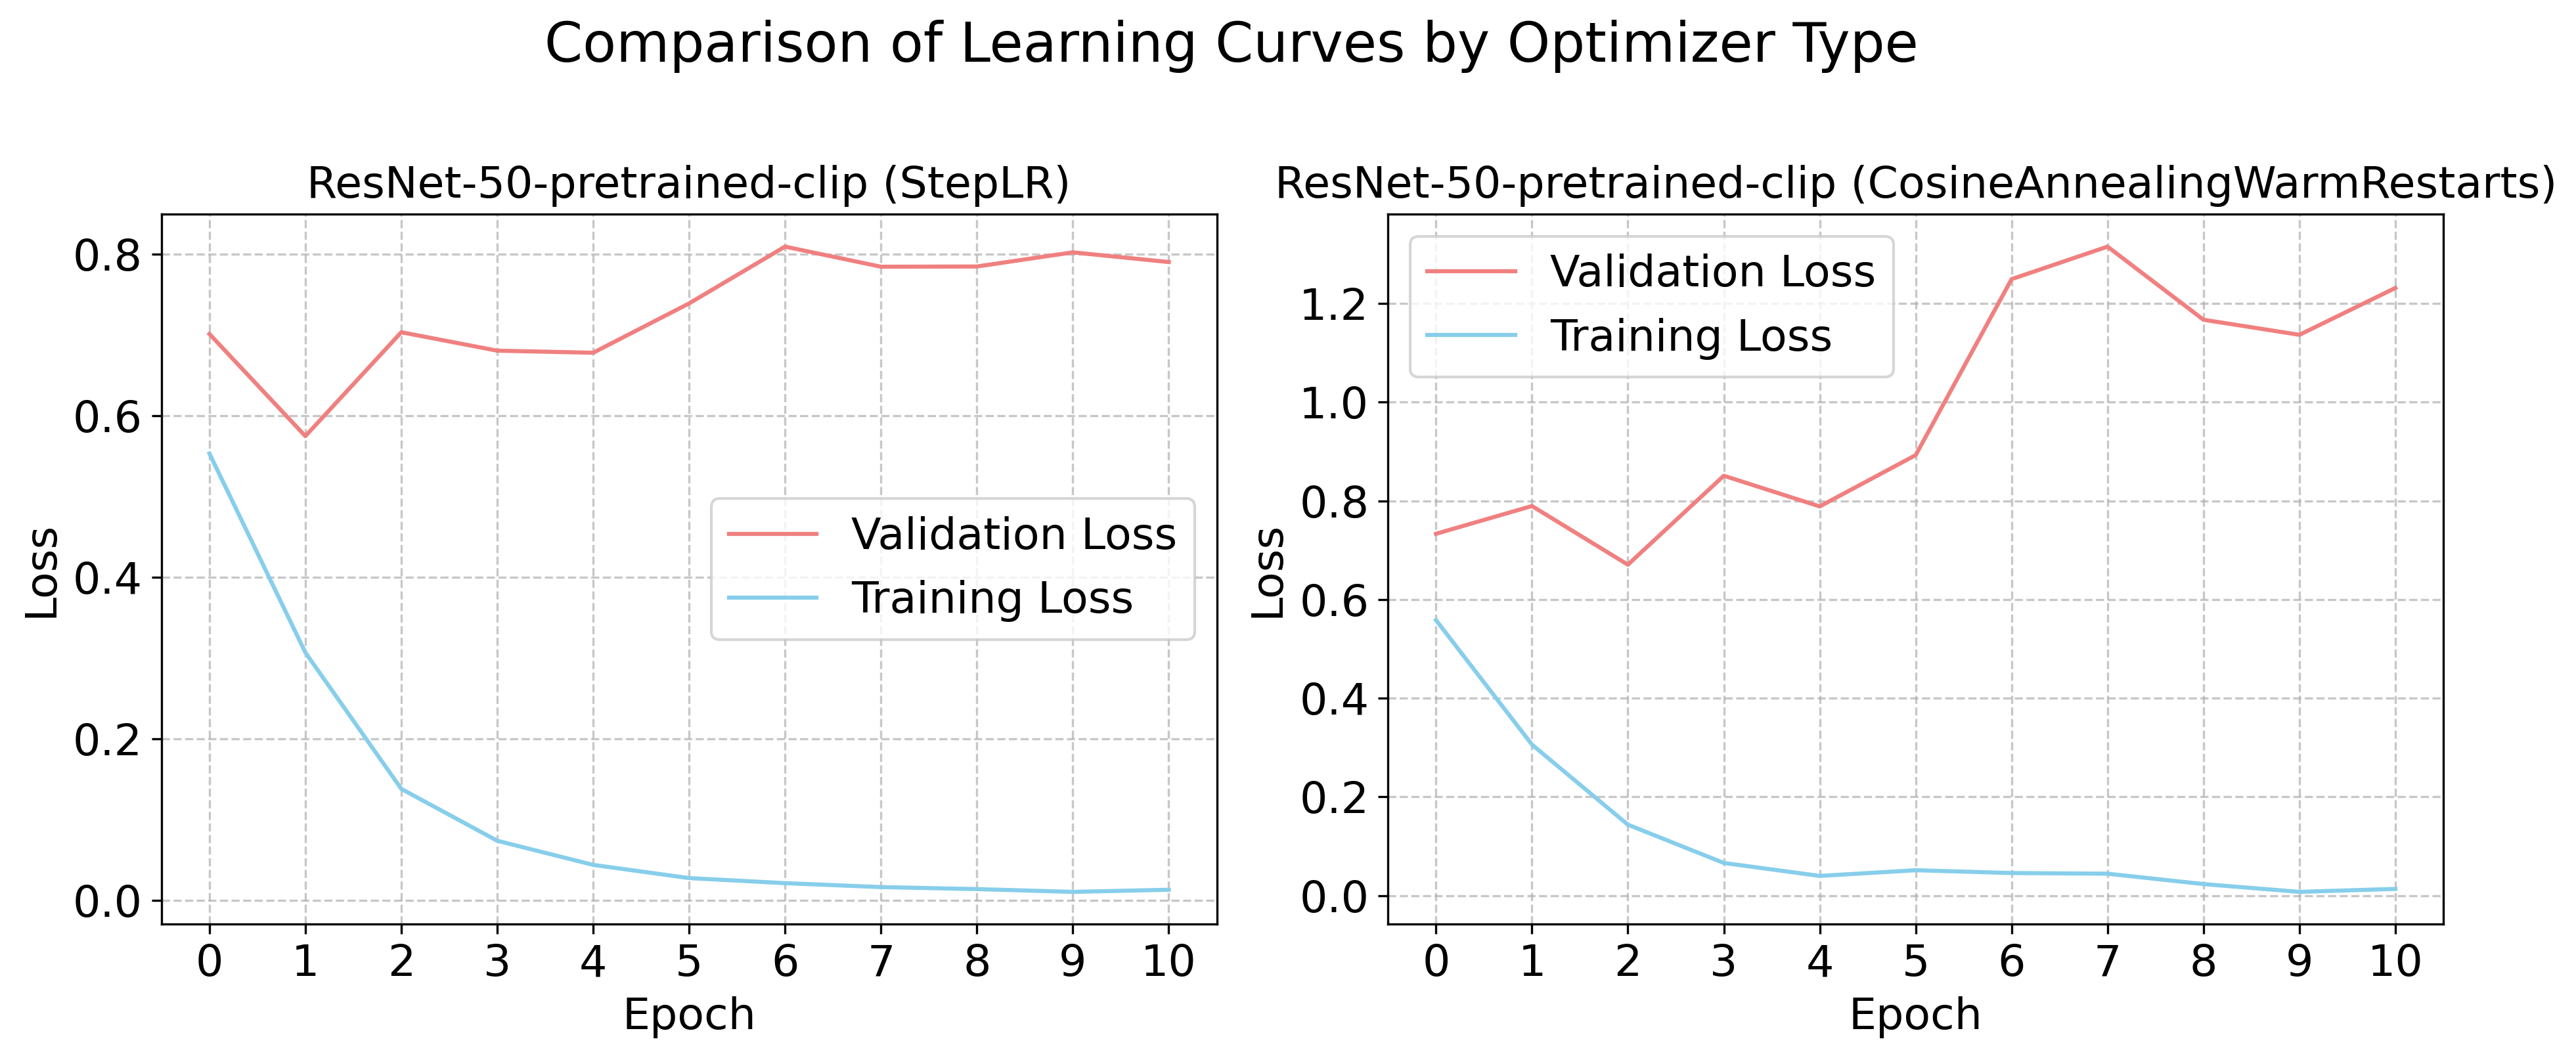

In [92]:
# Define the common model type to compare optimizers for
common_model_type = 'ResNet-50-pretrained-clip' # Or pick ConvNeXt-base, ViT-B-32, etc.

# Define the two optimization strategies
optimizer_type_1 = 'StepLR'
optimizer_type_2 = 'CosineAnnealingWarmRestarts' 

# Configuration for Plotting (unchanged from previous working version)
OUTPUT_DIR = "performance_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURE_WIDTH = 14 
FIGURE_HEIGHT = FIGURE_WIDTH * 0.4 # Adjusted height to maintain aspect ratio
FONTSIZE_TITLE = 18
FONTSIZE_SUBPLOT_TITLE = 16
FONTSIZE_LABELS = 16
FONTSIZE_TICKS = 16
FONTSIZE_LEGEND = 16
DPI = 300

# Create the figure and two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=DPI)

# Process and Plot for Optimizer Type 1
# Filter for the common model type AND the specific optimizer type
df_opt1 = experiment_results[
    (experiment_results['model'] == common_model_type) &
    (experiment_results['lr_scheduler_type'] == optimizer_type_1)
]

# Get the best model based on validation accuracy for this combination
if not df_opt1.empty:
    best_opt1_model_row = df_opt1.sort_values(by='val_acc', ascending=False).iloc[0]

    # Extract and convert history data
    train_loss_history_opt1 = ast.literal_eval(best_opt1_model_row['train_loss_history'])
    val_loss_history_opt1 = ast.literal_eval(best_opt1_model_row['val_loss_history'])
    NUM_EPOCHS = val_loss_history_opt1.index(None)

    # Plot on the first subplot (axes[0])
    axes[0].plot(val_loss_history_opt1, label='Validation Loss', color='lightcoral')
    axes[0].plot(train_loss_history_opt1, label='Training Loss', color='skyblue')
    axes[0].set_xticks(np.arange(0, NUM_EPOCHS, 1))
    axes[0].set_title(f'{common_model_type} ({optimizer_type_1})', fontsize=FONTSIZE_SUBPLOT_TITLE)
    axes[0].set_xlabel('Epoch', fontsize=FONTSIZE_LABELS)
    axes[0].set_ylabel('Loss', fontsize=FONTSIZE_LABELS)
    axes[0].tick_params(axis='x', labelsize=FONTSIZE_TICKS)
    axes[0].tick_params(axis='y', labelsize=FONTSIZE_TICKS)
    axes[0].grid(axis='both', linestyle='--', alpha=0.7)
    axes[0].legend(fontsize=FONTSIZE_LEGEND)
else:
    print(f"No data found for {common_model_type} with optimizer {optimizer_type_1}. Subplot 1 will be empty.")
    axes[0].set_title(f'No data for {optimizer_type_1}', fontsize=FONTSIZE_SUBPLOT_TITLE)


# Process and Plot for Optimizer Type 2 (e.g., Cosine Annealing)
# Filter for the common model type AND the specific optimizer type
df_opt2 = experiment_results[
    (experiment_results['model'] == common_model_type) &
    (experiment_results['lr_scheduler_type'] == optimizer_type_2)
]

# Get the best model based on validation accuracy for this combination
if not df_opt2.empty:
    best_opt2_model_row = df_opt2.sort_values(by='val_acc', ascending=False).iloc[0]

    # Extract and convert history data
    train_loss_history_opt2 = ast.literal_eval(best_opt2_model_row['train_loss_history'])
    val_loss_history_opt2 = ast.literal_eval(best_opt2_model_row['val_loss_history'])
    NUM_EPOCHS = val_loss_history_opt2.index(None)

    axes[1].plot(val_loss_history_opt2, label='Validation Loss', color='lightcoral')
    axes[1].plot(train_loss_history_opt2, label='Training Loss', color='skyblue')
    axes[1].set_xticks(np.arange(0, NUM_EPOCHS, 1))
    axes[1].set_title(f'{common_model_type} ({optimizer_type_2})', fontsize=FONTSIZE_SUBPLOT_TITLE)
    axes[1].set_xlabel('Epoch', fontsize=FONTSIZE_LABELS)
    axes[1].set_ylabel('Loss', fontsize=FONTSIZE_LABELS)
    axes[1].tick_params(axis='x', labelsize=FONTSIZE_TICKS)
    axes[1].tick_params(axis='y', labelsize=FONTSIZE_TICKS)
    axes[1].grid(axis='both', linestyle='--', alpha=0.7)
    axes[1].legend(fontsize=FONTSIZE_LEGEND)
else:
    print(f"No data found for {common_model_type} with optimizer {optimizer_type_2}. Subplot 2 will be empty.")
    axes[1].set_title(f'No data for {optimizer_type_2}', fontsize=FONTSIZE_SUBPLOT_TITLE)


# Add a main title for the entire figure
fig.suptitle('Comparison of Learning Curves by Optimizer Type', fontsize=FONTSIZE_TITLE + 2)

# Adjust layout
plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95])

# Save and display the plot
plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves_optimizer_comparison.png"), bbox_inches='tight')
plt.show()